
# Yeast eQTLs from **Genotypes + Expression** (BY × RM segregants)

**Objective:** Map eQTLs starting from **individual-level genotypes** and **expression** (no precomputed hotspot matrices), then visualize a *trans* hotspot (master regulator) pattern.

**Dataset:** Albert FW, Bloom JS, Siegel J, Day L, Kruglyak L (2018). *Genetics of trans-regulatory variation in gene expression.* **eLife** 7:e35471.


In [ ]:

#@title 0) Setup
!pip -q install pandas openpyxl pyarrow statsmodels matplotlib seaborn scikit-learn
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
os.makedirs("data", exist_ok=True)



## 1) Get the data (manual download), then upload here

**Paper link:** https://elifesciences.org/articles/35471/figures#files

**Download these three supplementary files from the article page:**
1. **Source Data 1** — `elife-35471-data1-v2.zip` (Expression matrix, log2 TPM)  
2. **Source Data 2** — `elife-35471-data2-v2.xlsx` (Covariates)  
3. **Source Data 3** — `elife-35471-data3-v2.zip` (Genotypes: BY = −1, RM = +1)

> After download: upload the ZIP/XLSX files using the widget below. ZIPs will be extracted automatically.


In [ ]:

#@title 1) Upload the three Source Data files
import os, zipfile, glob, shutil

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

uploader_available = False
try:
    from google.colab import files as colab_files
    uploader_available = True
    print("Select your files (you can multi-select):")
    uploaded = colab_files.upload()  # multi-file upload
    for fname in uploaded:
        dest = os.path.join(DATA_DIR, os.path.basename(fname))
        shutil.move(fname, dest)
        print("Saved ->", dest)
except Exception as e:
    print("Uploader not available. If running locally, place files under ./data and re-run next cell.")
    print("Current ./data contents:", os.listdir(DATA_DIR))

# Extract any ZIPs
for z in glob.glob(os.path.join(DATA_DIR, "*.zip")):
    print("Extracting", z)
    with zipfile.ZipFile(z, 'r') as zh:
        zh.extractall(DATA_DIR)

print("Data directory contents:", os.listdir(DATA_DIR))


Select your files (you can multi-select):


Data directory contents: []


## 2) Load expression (log2 TPM), covariates, and genotype matrix; align samples


In [ ]:
#@title 2) Load expression (SI_Data_01), covariates, and genotypes (SI_Data_03); align samples

# --- Loader for your specific formats + robust ID alignment ---

import re
import pandas as pd
import numpy as np

EXPR_PATH = "data/SI_Data_01_expressionValues.txt"
GENO_PATH = "data/SI_Data_03_genotypes.txt"
COV_PATH  = "data/elife-35471-data2-v2.xlsx"  # if your cov file differs, update path

# 1) Read expression (rows = samples like "A01_01-..."; cols = genes)
expr_raw = pd.read_csv(EXPR_PATH, sep="\t", header=0, index_col=0)

# 2) Read genotypes (rows = samples like "A01_01"; cols = markers)
geno_raw = pd.read_csv(GENO_PATH, sep="\t", header=0, index_col=0)

# 3) Read covariates (we'll auto-pick the column that contains sample IDs)
cov_raw = pd.read_excel(COV_PATH, sheet_name=0)

# --- helper to extract the well ID token "A01_01" from any string ---
WELL_RE = re.compile(r"([A-H][0-9]{2}_[0-9]{2})")

def well_id(s: str):
    if pd.isna(s):
        return None
    m = WELL_RE.search(str(s))
    return m.group(1) if m else None

# --- build sample IDs for each table ---

# Expression: its index has long labels; extract "A01_01"
expr = expr_raw.copy()
expr.index = expr.index.map(well_id)
expr = expr[expr.index.notnull()]
expr.index.name = "sample"

# Genotypes: its index is already "A01_01"; just ensure string and strip spaces
geno_mat = geno_raw.copy()
geno_mat.index = geno_mat.index.astype(str).str.strip()
geno_mat.index.name = "sample"

# Try to coerce genotype matrix to numeric (BY = -1, RM = +1)
for c in geno_mat.columns:
    geno_mat[c] = pd.to_numeric(geno_mat[c], errors="coerce")

# Covariates: find the column with the most recognizable "A01_01" tokens
best_col, best_hits = None, -1
for col in cov_raw.columns:
    hits = cov_raw[col].astype(str).map(well_id).notnull().sum()
    if hits > best_hits:
        best_col, best_hits = col, hits

if best_hits <= 0:
    raise ValueError("Could not find sample IDs in covariates. Inspect cov_raw to choose the correct column.")

cov = cov_raw.copy()
cov["__ID__"] = cov[best_col].astype(str).map(well_id)
cov = cov[cov["__ID__"].notnull()].set_index("__ID__", drop=True)
cov.index.name = "sample"
cov = cov[~cov.index.duplicated(keep="first")]

# --- align by shared sample IDs "A01_01" ---
common = expr.index.intersection(geno_mat.index).intersection(cov.index)
print("Common samples found:", len(common))
if len(common) < 5:
    print("expr IDs (first 10):", list(expr.index[:10]))
    print("geno IDs (first 10):", list(geno_mat.index[:10]))
    print("cov  IDs (first 10):", list(cov.index[:10]))
    raise ValueError("Too few overlapping samples — check that paths/inputs are correct.")

expr     = expr.loc[common].sort_index()
geno_mat = geno_mat.loc[common].sort_index()
cov      = cov.loc[common].sort_index()

print("Aligned shapes (samples × features):")
print("  expr:", expr.shape, " | geno:", geno_mat.shape, " | cov:", cov.shape)
display(expr.head(3))
display(geno_mat.iloc[:3, :5])
display(cov.head(3))



FileNotFoundError: [Errno 2] No such file or directory: 'data/SI_Data_01_expressionValues.txt'


## 3) Normalize expression & build covariates (inverse-normal + expression PCs)


In [ ]:
from sklearn.decomposition import PCA
from scipy.stats import rankdata, norm

USE_INV_NORMAL = True  #@param {type:"boolean"}
N_EXPR_PCS = 2         #@param {type:"slider", min:0, max:10, step:1}

X_expr = expr.copy()
if USE_INV_NORMAL:
    for g in X_expr.columns:
        r = rankdata(X_expr[g], method="average")
        u = (r - 0.5) / len(r)
        X_expr[g] = pd.Series(norm.ppf(u), index=X_expr.index)

pcs = None
if N_EXPR_PCS > 0:
    pca = PCA(n_components=N_EXPR_PCS, random_state=0)
    pcs_vals = pca.fit_transform(X_expr.fillna(X_expr.mean()))
    pcs = pd.DataFrame(pcs_vals, index=X_expr.index, columns=[f"exprPC{i+1}" for i in range(N_EXPR_PCS)])

C = pd.DataFrame(index=X_expr.index)
C["intercept"] = 1.0
cov_num = cov.select_dtypes(include=[np.number])
keep_cov = cov_num.columns[:5]
for c in keep_cov:
    C[c] = cov_num[c]
if pcs is not None:
    C = C.join(pcs)

C.head(3)



## 4) eQTL scan


In [ ]:

#@title 4A) Scan & rank markers by # significant genes
import statsmodels.api as sm
import numpy as np, pandas as pd

MAX_MARKERS = 200   #@param {type:"slider", min:200, max:20000, step:100}
MAX_GENES   = 200   #@param {type:"slider", min:200, max:6000, step:100}
PV_THRESH   = 1e-5   #@param {type:"number"}

genes = X_expr.columns[:MAX_GENES]
markers = geno_mat.columns[:MAX_MARKERS]

X_cov = C.copy()
hit_counts, top_hits = [], []

for m in markers:
    gvec = geno_mat[m]
    X = pd.concat([X_cov, gvec.rename("genotype")], axis=1)
    Xy = X.join(X_expr[genes]).dropna()
    pvals = []
    for g in genes:
        y = Xy[g].values
        XX = Xy.drop(columns=genes.tolist()).values
        fit = sm.OLS(y, XX).fit()
        pvals.append(fit.pvalues[-1] if len(fit.pvalues)>0 else np.nan)
    pvals = np.asarray(pvals, float)
    sig = np.isfinite(pvals) & (pvals < PV_THRESH)
    hit_counts.append(int(sig.sum()))
    top_idx = np.argsort(pvals)[:5]
    top_hits.append([(genes[i], float(pvals[i])) for i in top_idx])

hotspots = pd.DataFrame({"marker": markers, "n_sig": hit_counts}).sort_values("n_sig", ascending=False)
hotspots.head(10)


In [ ]:

#@title 4B) Plot eQTL ranking
import matplotlib.pyplot as plt, numpy as np
plt.figure(figsize=(8,3))
plt.plot(np.arange(len(hotspots))+1, hotspots["n_sig"].values, marker="o", ms=2, lw=1)
plt.xlabel("Marker rank")
plt.ylabel(f"# genes with p<{PV_THRESH:g}")
plt.title("Trans-hotspot strength ranking")
plt.tight_layout(); plt.show()

print("Top 5 markers and their top gene hits:")
for i in range(5):
    m = hotspots.iloc[i]["marker"]
    print(i+1, m, top_hits[list(markers).index(m)][:5])



## 5) Inspect a top marker (Manhattan-like view + genotype×expression)


In [ ]:

#@title 5A) Per-gene stats for chosen marker
TOP_MARKER_INDEX = 0  #@param {type:"slider", min:0, max:19, step:1}
best_marker = hotspots.iloc[TOP_MARKER_INDEX]["marker"]

gvec = geno_mat[best_marker]
X = pd.concat([C, gvec.rename("genotype")], axis=1).join(X_expr[genes]).dropna()

pvals, betas = [], []
for g in genes:
    y  = X[g].values
    XX = X.drop(columns=genes.tolist()).values
    fit = sm.OLS(y, XX).fit()
    betas.append(float(fit.params[-1]) if len(fit.params)>0 else np.nan)
    pvals.append(float(fit.pvalues[-1]) if len(fit.pvalues)>0 else np.nan)

res = pd.DataFrame({"gene": genes, "beta": betas, "p": pvals}).dropna()
res["mlog10p"] = -np.log10(res["p"] + 1e-300)
res = res.sort_values("p")

plt.figure(figsize=(8,3))
plt.scatter(np.arange(len(res)), res["mlog10p"].values, s=5)
plt.ylabel("-log10 p"); plt.xlabel("Genes (arbitrary order)")
plt.title(f"Top marker {best_marker}: genome-wide gene associations")
plt.tight_layout(); plt.show()

res.head(10)


In [ ]:

#@title 5B) Expression vs genotype for top 3 genes
top_genes = res.head(3)["gene"].tolist()

fig, axes = plt.subplots(1, len(top_genes),
                         figsize=(5 * len(top_genes), 4),
                         sharey=True)

if len(top_genes) == 1:
    axes = [axes]

for ax, g in zip(axes, top_genes):
    dfp = pd.concat([
        geno_mat[best_marker].rename("geno"),
        X_expr[g].rename("expr")
    ], axis=1).dropna()

    ax.scatter(dfp["geno"], dfp["expr"], alpha=0.6)
    pval = res.loc[res["gene"] == g, "p"].values[0]
    ax.set_title(f"{g}\n(p={pval:.1e})")
    ax.set_xlabel("Genotype (BY = -1, RM = +1)")
    ax.set_ylabel("Expression (normalized)")

plt.tight_layout()
plt.show()



### Extensions (optional)
- Add **BH-FDR** across genes for each marker, and count q<0.05 hits.
- Bring in **marker and gene coordinates** to classify **cis** vs **trans**.
- Compare hotspot strength with and without expression PCs.
- Cross-reference your top marker with Source Data 8 (hotspot overview) to see if it’s near **MKT1, HAP1, IRA2**, etc.


In [ ]:
#@title Build annotation tables (gene_annot & marker_annot) so the panel-A plot has real coordinates
# Upload ONE of these for genes (preferred):
#   - SGD_features.tab  (SGD "features" export; tab-delimited)
#   - sacCer3 GFF3 (or any GFF/GTF with chr/start/end/strand and systematic ORF IDs)
# Optional for markers (if regex can't parse names):
#   - a simple TSV/CSV with columns: marker, chr, pos
#
# After running this, re-run the improved panel-A plotting cell.

import os, io, re, glob
import pandas as pd
from IPython.display import display

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# ---------- 0) Helper: small uploader (Colab) ----------
try:
    from google.colab import files as colab_files
    print("Upload SGD_features.tab (or a GFF/GTF) and/or a marker-map file if you have one.")
    uploaded = colab_files.upload()
    for k,v in uploaded.items():
        with open(os.path.join(DATA_DIR, k), "wb") as f:
            f.write(v)
except:
    print("If not on Colab, place files under ./data and re-run.")

# ---------- 1) Build gene_annot ----------
def _looks_like_sgd_features(p):
    # Header usually contains: "Systematic name" / "Feature type" / "Chromosome" / "Start coordinate" / "Stop coordinate" / "Strand"
    try:
        with open(p, "r", encoding="utf-8", errors="ignore") as fh:
            head = fh.readline()
        return ("Systematic" in head and "Chromosome" in head) or p.lower().endswith(".tab")
    except:
        return False

def _looks_like_gff(p):
    return p.lower().endswith((".gff",".gff3",".gtf"))

def load_gene_annot():
    # Prefer SGD_features.tab if present
    cands = []
    cands += glob.glob(os.path.join(DATA_DIR, "*SGD*feature*.tab"))
    cands += glob.glob(os.path.join(DATA_DIR, "*features*.tab"))
    cands += glob.glob(os.path.join(DATA_DIR, "*.tab"))
    cands = [p for p in cands if _looks_like_sgd_features(p)]
    if cands:
        path = sorted(cands, key=lambda p: ("SGD_features" not in os.path.basename(p)))[0]
        print("Using gene features file:", path)
        df = pd.read_csv(path, sep="\t", header=0, dtype=str)
        # Keep Open Reading Frames (ORF) / protein_coding genes if present
        # Column names differ across exports; do robust selects
        colmap = {c.lower(): c for c in df.columns}
        syscol = colmap.get("systematic name") or colmap.get("systematic_name") or colmap.get("orf") or df.columns[0]
        chrcol = colmap.get("chromosome") or "Chromosome"
        startc = colmap.get("start coordinate") or colmap.get("start") or "Start coordinate"
        endc   = colmap.get("stop coordinate")  or colmap.get("end")   or "Stop coordinate"
        strand = colmap.get("strand") or "Strand"
        ftype  = colmap.get("feature type") or colmap.get("feature_type")

        # filter to genes/ORFs if feature type exists
        if ftype and ftype in df.columns:
            keep = df[ftype].str.contains("ORF|gene", case=False, na=False)
            df = df[keep].copy()

        # Clean chr labels (I..XVI or chrI..chrXVI)
        chr_series = df[chrcol].astype(str).str.replace("^chr","",regex=True).str.upper().str.replace("^0+","",regex=True)

        # TSS: start for '+'; end for '-' (if strand col exists)
        if strand in df.columns:
            tss = df.apply(lambda r: int(r[endc]) if str(r[strand]).strip()=="-" else int(r[startc]), axis=1)
        else:
            tss = df[startc].astype(int)

        ga = pd.DataFrame({
            "gene": df[syscol].astype(str).str.strip(),
            "chr": chr_series,
            "pos": tss
        }).dropna()
        ga = ga[ga["chr"].isin(["I","II","III","IV","V","VI","VII","VIII","IX","X","XI","XII","XIII","XIV","XV","XVI"])]
        ga = ga.drop_duplicates(subset=["gene"])
        return ga

    # Else, try any GFF/GTF
    cands = []
    cands += glob.glob(os.path.join(DATA_DIR, "*.gff"))
    cands += glob.glob(os.path.join(DATA_DIR, "*.gff3"))
    cands += glob.glob(os.path.join(DATA_DIR, "*.gtf"))
    cands = [p for p in cands if _looks_like_gff(p)]
    if cands:
        path = cands[0]
        print("Using GFF/GTF:", path)
        g = pd.read_csv(path, sep="\t", comment="#", header=None,
                        names=["chr","src","type","start","end","score","strand","phase","attr"])
        g["chr"] = g["chr"].astype(str).str.replace("^chr","",regex=True).str.upper().str.replace("^0+","",regex=True)
        # Extract systematic ORF ID from attributes (ID=YAL001C or gene_id=YAL001C, etc.)
        def get_orf(attr):
            m = re.search(r"(?:ID|Parent|gene_id|Name)=(Y[A-P][LR]\w+)", str(attr))
            return m.group(1) if m else None
        g["gene"] = g["attr"].map(get_orf)
        g = g[g["gene"].notna()]
        # TSS by strand
        g["pos"] = g.apply(lambda r: int(r["end"]) if str(r["strand"]).strip()=="-" else int(r["start"]), axis=1)
        ga = g[["gene","chr","pos"]].drop_duplicates(subset=["gene"])
        ga = ga[ga["chr"].isin(["I","II","III","IV","V","VI","VII","VIII","IX","X","XI","XII","XIII","XIV","XV","XVI"])]
        return ga

    print("No gene features file found. Upload SGD_features.tab or a sacCer3 GFF3 to data/.")
    return None

gene_annot = load_gene_annot()
if isinstance(gene_annot, pd.DataFrame):
    print(f"gene_annot rows: {len(gene_annot)}")
    display(gene_annot.head())
    gene_annot.to_csv("gene_annot.tsv", sep="\t", index=False)

# ---------- 2) Build marker_annot ----------
# First, try to parse from marker names (roman numerals or numbers with positions embedded)
def parse_marker_chr_pos(name: str):
    s = str(name)
    # chrXII_12345, XII:12345
    m = re.search(r"(?:chr)?\s*([IVXLCDM]+)[\s_:-]+(\d+)", s, flags=re.I)
    if m:
        roman = m.group(1).upper()
        pos   = int(m.group(2))
        ok = {"I","II","III","IV","V","VI","VII","VIII","IX","X","XI","XII","XIII","XIV","XV","XVI"}
        return (roman if roman in ok else None), pos
    # chr12_12345 or 12:12345
    m = re.search(r"(?:chr)?\s*(\d+)[\s_:-]+(\d+)", s, flags=re.I)
    if m:
        num = int(m.group(1)); pos = int(m.group(2))
        if 1 <= num <= 16:
            order = ["I","II","III","IV","V","VI","VII","VIII","IX","X","XI","XII","XIII","XIV","XV","XVI"]
            return order[num-1], pos
    return None, None

marker_annot = None
if 'geno_mat' in globals():
    mk = pd.DataFrame({"marker": list(geno_mat.columns)})
    parsed = mk["marker"].apply(parse_marker_chr_pos)
    mk["chr"] = [p[0] for p in parsed]
    mk["pos"] = [p[1] for p in parsed]
    success = mk["chr"].notna().sum()
    print(f"Parsed chr/pos from marker names for {success} / {len(mk)} markers.")
    if success > 50:  # threshold: enough to be useful
        marker_annot = mk[mk["chr"].notna()].copy()
        marker_annot.to_csv("marker_annot.tsv", sep="\t", index=False)

# If not enough parsed, look for a user-provided map file
if (marker_annot is None) or (marker_annot.shape[0] < 50):
    print("If many markers are still missing positions, upload a marker map (TSV/CSV) with columns: marker, chr, pos.")
    mm = []
    mm += glob.glob(os.path.join(DATA_DIR, "*marker*map*.tsv"))
    mm += glob.glob(os.path.join(DATA_DIR, "*marker*map*.csv"))
    mm += glob.glob(os.path.join(DATA_DIR, "*markers*.tsv"))
    mm += glob.glob(os.path.join(DATA_DIR, "*markers*.csv"))
    for path in mm:
        df = pd.read_csv(path, sep="\t" if path.endswith(".tsv") else ",")
        cols = {c.lower():c for c in df.columns}
        if {"marker","chr","pos"}.issubset(cols.keys()):
            marker_annot = df[[cols["marker"], cols["chr"], cols["pos"]]].copy()
            marker_annot.columns = ["marker","chr","pos"]
            marker_annot["chr"] = marker_annot["chr"].astype(str).str.replace("^chr","",regex=True).str.upper().str.replace("^0+","",regex=True)
            marker_annot.to_csv("marker_annot.tsv", sep="\t", index=False)
            print("Loaded marker map:", path)
            break

if isinstance(marker_annot, pd.DataFrame):
    print(f"marker_annot rows: {len(marker_annot)}")
    display(marker_annot.head())
else:
    print("Marker positions still incomplete. The plot will still draw but fewer points will have coordinates.")

print("\n✅ Annotations prepared (if inputs were provided). Now re-run the improved panel-A plotting cell.")


Upload SGD_features.tab (or a GFF/GTF) and/or a marker-map file if you have one.


Saving saccharomyces_cerevisiae_R64-2-1_20150113.gff to saccharomyces_cerevisiae_R64-2-1_20150113.gff
Using GFF/GTF: data/saccharomyces_cerevisiae_R64-2-1_20150113.gff


/tmp/ipython-input-431970141.py:94: DtypeWarning: Columns (1,2,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  g = pd.read_csv(path, sep="\t", comment="#", header=None,


gene_annot rows: 12826


,gene,chr,pos
5,YAL069W,I,335
6,YAL069W_mRNA,I,335
8,YAL068W,I,538
12,YAL068C,I,2169
13,YAL068C_mRNA,I,2169


If many markers are still missing positions, upload a marker map (TSV/CSV) with columns: marker, chr, pos.
Marker positions still incomplete. The plot will still draw but fewer points will have coordinates.

✅ Annotations prepared (if inputs were provided). Now re-run the improved panel-A plotting cell.


Upload elife-35471-data9.xlsx


Saving elife-35471-data9.xlsx to elife-35471-data9.xlsx
Using: elife-35471-data9.xlsx | saccharomyces_cerevisiae_R64-2-1_20150113.gff
Loaded data9: genes=5629 markers=102 (sheet='SI_Data_09_hotspotEffects')
Parsed markers: 102 usable
Points plotted: 5626 / genes input: 5629 | markers parsed: 102


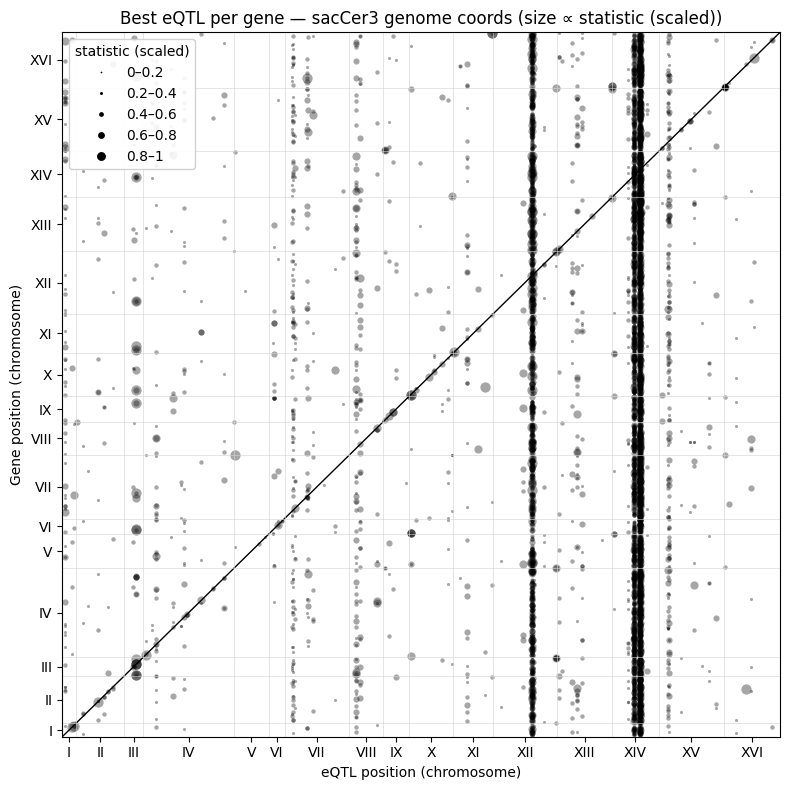

In [ ]:
#@title Build best_hits from data9.xlsx and plot Panel A using sacCer3 GFF
import os, re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------- paths / upload --------------------
DATA = "data"; os.makedirs(DATA, exist_ok=True)

# data9 (gene × marker)
data9_path = None
for p in [os.path.join(DATA,"elife-35471-data9.xlsx"),
          os.path.join(DATA,"elife_35471_data9.xlsx"),
          "elife-35471-data9.xlsx"]:
    if os.path.exists(p): data9_path = p; break
if data9_path is None:
    try:
        from google.colab import files
        print("Upload elife-35471-data9.xlsx")
        up = files.upload()
        for k,v in up.items():
            p = os.path.join(DATA,k); open(p,"wb").write(v); data9_path = p; break
    except Exception:
        raise FileNotFoundError("Provide elife-35471-data9.xlsx")

# sacCer3 GFF/GFF3 (SGD S288C R64 or equivalent)
gff_path = None
for q in os.listdir(DATA):
    if re.search(r"\.gff3?$", q, re.I): gff_path = os.path.join(DATA,q); break
if gff_path is None:
    try:
        from google.colab import files
        print("Upload sacCer3 GFF/GFF3 (e.g., S288C_reference_genome_R64-*.gff)")
        up = files.upload()
        for k,v in up.items():
            if re.search(r"\.gff3?$", k, re.I):
                p = os.path.join(DATA,k); open(p,"wb").write(v); gff_path = p; break
    except Exception:
        raise FileNotFoundError("Provide a sacCer3 GFF/GFF3 in ./data")

print("Using:", os.path.basename(data9_path), "|", os.path.basename(gff_path))

# -------------------- sacCer3 constants --------------------
CHR_ORDER = ["I","II","III","IV","V","VI","VII","VIII","IX","X","XI","XII","XIII","XIV","XV","XVI"]
CHR_LEN = {"I":230218,"II":813184,"III":316620,"IV":1531933,"V":576874,"VI":270161,"VII":1090940,
           "VIII":562643,"IX":439888,"X":745751,"XI":666816,"XII":1078177,"XIII":924431,
           "XIV":784333,"XV":1091291,"XVI":948066}
CUM_START = {}; _run=0
for c in CHR_ORDER: CUM_START[c]=_run; _run+=CHR_LEN[c]
GENOME_LEN = _run
ACC2CHR = {"NC_001133.9":"I","NC_001134.8":"II","NC_001135.5":"III","NC_001136.10":"IV",
           "NC_001137.3":"V","NC_001138.5":"VI","NC_001139.9":"VII","NC_001140.6":"VIII",
           "NC_001141.2":"IX","NC_001142.9":"X","NC_001143.9":"XI","NC_001144.5":"XII",
           "NC_001145.3":"XIII","NC_001146.8":"XIV","NC_001147.6":"XV","NC_001148.4":"XVI"}

def norm_chr(x:str):
    s = str(x)
    s = ACC2CHR.get(s, s)
    s = re.sub(r"^chr","", s, flags=re.I)
    s = re.sub(r"^0+","", s).upper()
    if s.isdigit():
        n=int(s);
        if 1<=n<=16: s = CHR_ORDER[n-1]
    return s if s in CHR_ORDER else None

def parse_marker(name:str):
    # 'chrXIV:12345_A/G', 'XII:33040', '12:33040', 'chr12_33040'
    m = re.search(r"(?:chr)?\s*([IVXLCDM]+|\d+)[\s:_-]+(\d+)", str(name), flags=re.I)
    if not m: return None, None
    ch = norm_chr(m.group(1)); pos = int(m.group(2))
    return (ch,pos) if (ch in CHR_ORDER) else (None,None)

# -------------------- load data9 (gene × marker) --------------------
xls = pd.ExcelFile(data9_path)
sheet = xls.sheet_names[0]
M = xls.parse(sheet)
# assume first col = gene; remaining columns are marker names
gene_col = M.columns[0]
genes = M[gene_col].astype(str)
matrix = M.drop(columns=[gene_col]).apply(pd.to_numeric, errors="coerce")
matrix.index = genes
print(f"Loaded data9: genes={matrix.shape[0]} markers={matrix.shape[1]} (sheet='{sheet}')")

# keep only marker-like columns
marker_cols = []
for c in matrix.columns:
    ch,pos = parse_marker(c)
    if ch and isinstance(pos,int): marker_cols.append(c)
matrix = matrix[marker_cols]
print(f"Parsed markers: {len(marker_cols)} usable")

# -------------------- load GFF and build gene coordinates --------------------
G = pd.read_csv(
    gff_path, sep="\t", comment="#", header=None,
    names=["chr","src","type","start","end","score","strand","phase","attr"],
    dtype={"chr":str,"start":float,"end":float,"strand":str,"attr":str},
    low_memory=False
).dropna(subset=["start","end"])

def extract_orf(attr:str):
    if not isinstance(attr,str): return None
    m = re.search(r"locus_tag=(Y[A-P][LR]\d+[WC](?:-[A-Z])?)", attr, flags=re.I)
    if m: return m.group(1).upper()
    m = re.search(r"ID=gene-(Y[A-P][LR]\d+[WC](?:-[A-Z])?)", attr, flags=re.I)
    if m: return m.group(1).upper()
    m = re.search(r"(?:Name|gene)=([A-Za-z0-9_-]+)", attr)  # standard name
    nm = m.group(1).upper() if m else None
    # fallback: any ORF pattern inside
    m2 = re.search(r"(Y[A-P][LR]\d+[WC](?:-[A-Z])?)", attr, flags=re.I)
    return (m2.group(1).upper() if m2 else nm)

G["gene"] = G["attr"].apply(extract_orf)
G["chr"]  = G["chr"].map(norm_chr)
G = G[G["gene"].notna() & G["chr"].notna()].copy()

# pick TSS per gene by strand (start for '+', end for '-')
strand_map = G.groupby("gene")["strand"].agg(lambda s: s.dropna().iloc[0] if len(s.dropna()) else "+").to_dict()
tmp = G.groupby(["gene","chr"]).agg(start_min=("start","min"), end_max=("end","max")).reset_index()
tmp["strand"] = tmp["gene"].map(strand_map)
tmp["pos"] = np.where(tmp["strand"].isin(["-","-1"]), tmp["end_max"], tmp["start_min"]).astype(int)
GA = tmp[["gene","chr","pos"]].drop_duplicates("gene")
GA = GA[GA["chr"].isin(CHR_ORDER)].copy()
GA["gene_cum"] = [CUM_START[c]+int(p) for c,p in zip(GA["chr"], GA["pos"])]
gene_cum = GA.set_index("gene")["gene_cum"].to_dict()

# If data9 gene labels are standard names, map them via GFF Name->ORF when possible
name_to_orf = {}
for _,r in G.iterrows():
    # map Name=FOO -> ORF if both present
    m_name = re.search(r"(?:Name|gene)=([A-Za-z0-9_-]+)", str(r["attr"]))
    m_orf  = re.search(r"(Y[A-P][LR]\d+[WC](?:-[A-Z])?)", str(r["attr"]), flags=re.I)
    if m_name and m_orf:
        name_to_orf.setdefault(m_name.group(1).upper(), m_orf.group(1).upper())

idx_upper = pd.Index([g.upper() for g in matrix.index])
gene_keys = []
for g in idx_upper:
    if re.match(r"^Y[A-P][LR]\d+[WC](?:-[A-Z])?$", g): gene_keys.append(g)
    else: gene_keys.append(name_to_orf.get(g, g))

matrix.index = gene_keys

# -------------------- best marker per gene --------------------
vals = matrix.to_numpy(dtype=float)
abs_vals = np.abs(vals)
best_j = np.nanargmax(abs_vals, axis=1)
best_marker = [matrix.columns[j] for j in best_j]
best_stat = abs_vals[np.arange(abs_vals.shape[0]), best_j]

# scale to 0..1 for point sizes (if already 0..1, keep as-is)
if np.nanmax(vals) <= 1.2 and np.nanmin(vals) >= -0.2:
    R2 = np.clip(best_stat, 0, 1)
    size_label = "variance fraction"
else:
    vmin, vmax = np.nanmin(best_stat), np.nanmax(best_stat)
    R2 = (best_stat - vmin) / (vmax - vmin + 1e-12)
    size_label = "statistic (scaled)"

best_hits = pd.DataFrame({"gene": matrix.index.astype(str),
                          "marker": best_marker,
                          "R2": R2})

# -------------------- genome coordinates for markers --------------------
mk = pd.DataFrame({"marker": matrix.columns})
mk[["m_chr","m_pos"]] = mk["marker"].apply(lambda s: pd.Series(parse_marker(s)))
mk = mk.dropna(subset=["m_chr","m_pos"])
mk = mk[mk["m_chr"].isin(CHR_ORDER)]
mk["m_pos"] = mk["m_pos"].astype(int)
mk["m_cum"] = [CUM_START[c]+p for c,p in zip(mk["m_chr"], mk["m_pos"])]
mark_cum = mk.set_index("marker")["m_cum"].to_dict()

# -------------------- assemble points --------------------
x_vals, y_vals, r2_vals = [], [], []
for g, m, r2 in zip(best_hits["gene"], best_hits["marker"], best_hits["R2"]):
    gx = gene_cum.get(str(g).upper())
    mx = mark_cum.get(str(m))
    if gx is not None and mx is not None and np.isfinite(gx) and np.isfinite(mx):
        y_vals.append(float(gx)); x_vals.append(float(mx)); r2_vals.append(float(r2))

x = np.array(x_vals); y = np.array(y_vals); r2v = np.array(r2_vals)
print(f"Points plotted: {len(x)} / genes input: {len(best_hits)} | markers parsed: {len(mark_cum)}")

# -------------------- plot Panel A --------------------
bins, sizes, labels = [0,0.2,0.4,0.6,0.8,1.01],[5,10,20,35,55],["0–0.2","0.2–0.4","0.4–0.6","0.6–0.8","0.8–1"]
fig, ax = plt.subplots(figsize=(8,8))
for i in range(len(bins)-1):
    m = (r2v >= bins[i]) & (r2v < bins[i+1])
    if m.any():
        ax.scatter(x[m], y[m], s=sizes[i], color="black", alpha=0.35, linewidths=0)

# diagonal & chromosome grid
ax.plot([0,GENOME_LEN],[0,GENOME_LEN], color="black", lw=1)
for c in CHR_ORDER:
    v = CUM_START[c]
    ax.axvline(v, color="lightgrey", lw=0.6, alpha=0.7)
    ax.axhline(v, color="lightgrey", lw=0.6, alpha=0.7)
xticks = [CUM_START[c]+CHR_LEN[c]/2 for c in CHR_ORDER]
ax.set_xticks(xticks); ax.set_xticklabels(CHR_ORDER)
ax.set_yticks(xticks); ax.set_yticklabels(CHR_ORDER)
ax.set_xlim(0, GENOME_LEN); ax.set_ylim(0, GENOME_LEN)
ax.set_xlabel("eQTL position (chromosome)")
ax.set_ylabel("Gene position (chromosome)")
ax.set_title("Best eQTL per gene — sacCer3 genome coords (size ∝ " + size_label + ")")

legend_elems = [Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
                       markersize=np.sqrt(s), label=l) for s,l in zip(sizes,labels)]
ax.legend(handles=legend_elems, title=size_label, loc="upper left",
          frameon=True, framealpha=0.9)
plt.tight_layout(); plt.show()